In [40]:
# Import Library
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

# Data Splitting
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Missing values
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer

# Scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.preprocessing import RobustScaler

# Encoding
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder, OrdinalEncoder

# Cross Validation
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate  # regresi

# Modeling
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# polynomial features
from sklearn.preprocessing import PolynomialFeatures

# Metrics Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tools.eval_measures import rmse

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import make_scorer, fbeta_score


# imbalanced
from imblearn.under_sampling import RandomUnderSampler, CondensedNearestNeighbour, NearMiss
from imblearn.over_sampling import RandomOverSampler, SMOTE

In [2]:
## Business Problem Understanding

## 1. Context
Perusahaan Travel Insurance menjual berbagai produk asuransi perjalanan kepada customer melalui beberapa <b>agency</b> dan <b>distribution channel</b>, dengan berbagai destinasi perjalanan dan durasi perjalanan.

* Setiap transaksi memiliki informasi seperti:
* Agency
* Agency Type
* Distribution Channel
* Product Name
* Gender
* Duration
* Destination
* Net Sales
* Commission
* Age
* Claim

Salah satu tantangan bagi perusahaan asuransi adalah <b>ketidakpastian customer yang akan mengajukan klaim</b>. Jika perusahaan dapat memahami karakteristik yang berkaitan dengan klaim dan memprediksi kemungkinan klaim sejak awal, perusahaan dapat melakukan risk assessment dengan lebih baik dan membuat keputusan bisnis yang lebih data-driven.

## 2. Problem Statement
Bagaimana perusahaan dapat mengidentifikasi faktor-faktor yang memengaruhi kemungkinan customer melakukan claim dan membangun model untuk memprediksi apakah suatu transaksi Travel Insurance akan menghasilkan claim atau tidak?

## 3. Goals
Maka berdasarkan permasalahan tersebut, perusahaan <b>Travel Insurance</b> ingin memiliki kemampuan untuk <b>memprediksi kemungkinan seorang customer akan mengajukan klaim atau tidak</b>, sehingga perusahaan dapat mengidentifikasi customer atau transaksi yang memiliki <b>potensi risiko klaim lebih tinggi</b> dan dapat melakukan pengelolaan risiko serta perencanaan penanganan klaim dengan lebih baik.
Dan juga, perusahaan ingin mengetahui <b>faktor atau variabel apa saja yang mempengaruhi kemungkinan customer mengajukan klaim</b>, seperti <b>jenis produk asuransi, destinasi perjalanan, durasi perjalanan, usia customer, agency, dan distribution channel</b>, sehingga perusahaan dapat membuat <b>strategi produk, risk assessment, dan pengelolaan sumber daya yang lebih tepat</b> untuk mengurangi risiko dan meningkatkan efektivitas bisnis Travel Insurance.

## 4. Analytic Approach
Menggunakan pendekatan <b>Supervised Learning – Classification</b> untuk memprediksi kemungkinan customer melakukan <b>claim atau tidak</b>. Analisis dilakukan melalui tahap <b>data preparation, exploratory data analysis (EDA), dan feature engineering</b> untuk memahami karakteristik serta faktor-faktor yang berkaitan dengan terjadinya claim. Selanjutnya, dibangun dan dibandingkan tiga model classification, yaitu <b>Logistic Regression, Random Forest, dan XGBoost</b>, untuk menentukan model yang paling sesuai dalam memprediksi kemungkinan customer melakukan claim.

## 5. Metode Evaluation
Performa model akan dievaluasi menggunakan <b>Precision, Recall, F1-Score, F2-Score, ROC-AUC, dan Confusion Matrix. F2-Score digunakan sebagai metric utama</b> karena perusahaan lebih memprioritaskan kemampuan model dalam mengidentifikasi customer yang berpotensi melakukan claim (<b>Recall</b>). Dengan demikian, model diharapkan dapat meminimalkan <b>False Negative</b>, yaitu kondisi ketika customer yang sebenarnya melakukan claim diprediksi tidak melakukan claim.


In [101]:
df = pd.read_csv('../dataset/data_travel_insurance.csv')
df.head(20)

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age,Claim
0,C2B,Airlines,Online,Annual Silver Plan,F,365,SINGAPORE,216.00,54.00,57,No
1,EPX,Travel Agency,Online,Cancellation Plan,NaN,4,MALAYSIA,10.00,0.00,33,No
2,JZI,Airlines,Online,Basic Plan,M,19,INDIA,22.00,7.70,26,No
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,20,UNITED STATES,112.00,0.00,59,No
4,C2B,Airlines,Online,Bronze Plan,M,8,SINGAPORE,16.00,4.00,28,No
5,EPX,Travel Agency,Online,Cancellation Plan,NaN,2,SINGAPORE,10.00,0.00,36,No
6,EPX,Travel Agency,Online,1 way Comprehensive Plan,NaN,25,"KOREA, REPUBLIC OF",50.00,0.00,36,No
7,EPX,Travel Agency,Online,Cancellation Plan,NaN,90,SINGAPORE,78.00,0.00,22,No
8,JZI,Airlines,Online,Basic Plan,M,4,THAILAND,22.00,7.70,39,No
9,EPX,Travel Agency,Online,Cancellation Plan,NaN,24,GERMANY,80.00,0.00,36,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44328 entries, 0 to 44327
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                44328 non-null  str    
 1   Agency Type           44328 non-null  str    
 2   Distribution Channel  44328 non-null  str    
 3   Product Name          44328 non-null  str    
 4   Gender                12681 non-null  str    
 5   Duration              44328 non-null  int64  
 6   Destination           44328 non-null  str    
 7   Net Sales             44328 non-null  float64
 8   Commision (in value)  44328 non-null  float64
 9   Age                   44328 non-null  int64  
 10  Claim                 44328 non-null  str    
dtypes: float64(2), int64(2), str(7)
memory usage: 5.9 MB


In [4]:
## 2. Exploratory Data Analysis (EDA)

In [5]:
# select column dengan value Gender is NaN dan maksimal 10 baris
df.loc[df['Gender'].isna(), ['Agency', 'Agency Type', 'Distribution Channel', 'Product Name', 
                             'Gender','Duration','Destination','Net Sales','Commision (in value)', 'Age', 'Claim']].head(10)

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age,Claim
1,EPX,Travel Agency,Online,Cancellation Plan,NaN,4,MALAYSIA,10.0,0.0,33,No
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,20,UNITED STATES,112.0,0.0,59,No
5,EPX,Travel Agency,Online,Cancellation Plan,NaN,2,SINGAPORE,10.0,0.0,36,No
6,EPX,Travel Agency,Online,1 way Comprehensive Plan,NaN,25,"KOREA, REPUBLIC OF",50.0,0.0,36,No
7,EPX,Travel Agency,Online,Cancellation Plan,NaN,90,SINGAPORE,78.0,0.0,22,No
9,EPX,Travel Agency,Online,Cancellation Plan,NaN,24,GERMANY,80.0,0.0,36,No
10,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,43,JAPAN,40.0,0.0,28,No
14,EPX,Travel Agency,Online,Cancellation Plan,NaN,6,SINGAPORE,10.0,0.0,43,No
15,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,16,INDONESIA,47.0,0.0,36,No
16,EPX,Travel Agency,Online,1 way Comprehensive Plan,NaN,8,JAPAN,25.0,0.0,27,No


In [6]:
# check Distribution channel value
df["Distribution Channel"].unique()

<ArrowStringArray>
['Online', 'Offline']
Length: 2, dtype: str

In [7]:
# check Gender value
df["Gender"].unique()

<ArrowStringArray>
['F', nan, 'M']
Length: 3, dtype: str

In [8]:
df["Gender"].isna().sum()

np.int64(31647)

In [9]:
df['Gender'].isna().mean() * 100

np.float64(71.39279913373038)

In [10]:
# dikarenakan sebanyak 71.3% data memiliki Gender is NA, maka diisi dengan unknown
df['Gender'] = df['Gender'].fillna('Unknown')

In [11]:
# Cek apakah Gender memiliki korelasi dengan Claim
df.groupby(df['Gender'].fillna('Unknown'))['Claim'].value_counts(normalize=True)

Gender   Claim
F        No       0.958880
         Yes      0.041120
M        No       0.966021
         Yes      0.033979
Unknown  No       0.993617
         Yes      0.006383
Name: proportion, dtype: float64

In [35]:
### NEED TO CHECK GENDER COLUMN, WHETHER DELETE OR NOT

In [12]:
# check Claim value
df["Claim"].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [13]:
# check Product Name
df["Agency Type"].unique()

<ArrowStringArray>
['Airlines', 'Travel Agency']
Length: 2, dtype: str

In [14]:
df.isna().sum()

Agency                  0
Agency Type             0
Distribution Channel    0
Product Name            0
Gender                  0
Duration                0
Destination             0
Net Sales               0
Commision (in value)    0
Age                     0
Claim                   0
dtype: int64

In [15]:
# cek data duplicate
df.duplicated().sum()

np.int64(4667)

In [16]:
# cek semua baris dan grup duplikatnya
duplicateRow = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(20)
duplicateRow

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age,Claim
10217,ART,Airlines,Online,24 Protect,M,3,MALAYSIA,4.99,1.75,48,No
22009,ART,Airlines,Online,24 Protect,M,3,MALAYSIA,4.99,1.75,48,No
19436,ART,Airlines,Online,Value Plan,M,18,CHINA,61.00,21.35,118,No
31570,ART,Airlines,Online,Value Plan,M,18,CHINA,61.00,21.35,118,No
38456,ART,Airlines,Online,Value Plan,M,31,THAILAND,29.00,10.15,118,No
43985,ART,Airlines,Online,Value Plan,M,31,THAILAND,29.00,10.15,118,No
1849,C2B,Airlines,Online,Annual Gold Plan,F,365,SINGAPORE,389.35,97.34,33,No
26521,C2B,Airlines,Online,Annual Gold Plan,F,365,SINGAPORE,389.35,97.34,33,No
10496,C2B,Airlines,Online,Annual Gold Plan,M,364,SINGAPORE,333.00,83.25,35,No
14317,C2B,Airlines,Online,Annual Gold Plan,M,364,SINGAPORE,333.00,83.25,35,No


In [20]:
# Drop data duplicate dengan variable name is df_clean
df_clean = df.drop_duplicates()
df_clean.shape

(39661, 11)

In [21]:
# cek data duplicate setelah dilakukan drop
df_clean.duplicated().sum()

np.int64(0)

In [22]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 39661 entries, 0 to 44327
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                39661 non-null  str    
 1   Agency Type           39661 non-null  str    
 2   Distribution Channel  39661 non-null  str    
 3   Product Name          39661 non-null  str    
 4   Gender                39661 non-null  str    
 5   Duration              39661 non-null  int64  
 6   Destination           39661 non-null  str    
 7   Net Sales             39661 non-null  float64
 8   Commision (in value)  39661 non-null  float64
 9   Age                   39661 non-null  int64  
 10  Claim                 39661 non-null  str    
dtypes: float64(2), int64(2), str(7)
memory usage: 5.8 MB


In [23]:
df_clean['Claim'].value_counts() / len(df_clean['Claim'])
# sebanyak 98% Travel Insurance dengan Claim status is False
# sebanyak 17% Travel Insurance dengan Claim status is True

Claim
No     0.982981
Yes    0.017019
Name: count, dtype: float64

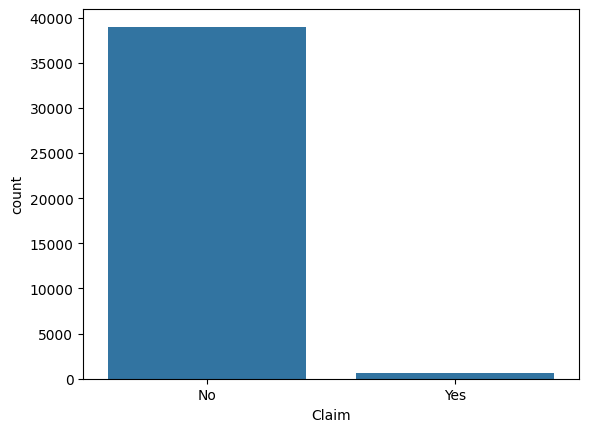

In [24]:
grafikTarget = sns.countplot(data = df_clean, x = 'Claim')

<Axes: xlabel='Age', ylabel='Count'>

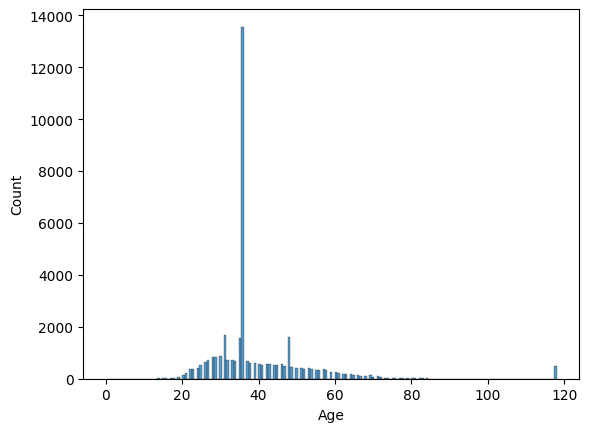

In [25]:
# cek age distribution, anomali data
sns.histplot(data = df_clean, x='Age')

<Axes: xlabel='Duration', ylabel='Count'>

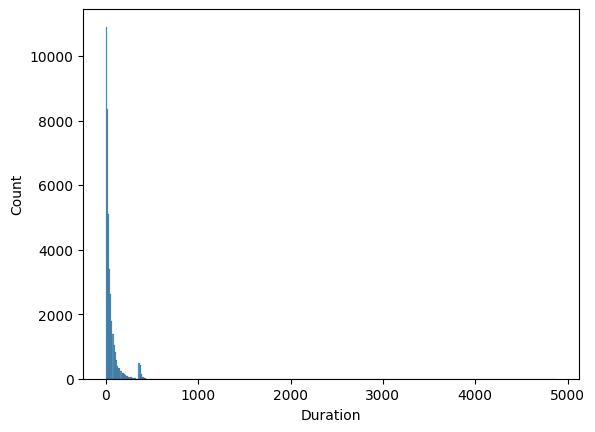

In [26]:
# cek Duration distribution, anomali data
sns.histplot(data = df_clean, x='Duration')

In [27]:
# 3. Define X and y
X = df_clean.drop(columns='Claim')
X.head(3)

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age
0,C2B,Airlines,Online,Annual Silver Plan,F,365,SINGAPORE,216.0,54.0,57
1,EPX,Travel Agency,Online,Cancellation Plan,Unknown,4,MALAYSIA,10.0,0.0,33
2,JZI,Airlines,Online,Basic Plan,M,19,INDIA,22.0,7.7,26


In [28]:
y = df_clean['Claim']
y.head(3)

0    No
1    No
2    No
Name: Claim, dtype: str

In [29]:
y = y.map({
    'Yes':0, # claim the travel insurance
    'No':1 # no claim the travel insurance
})
y

0        1
1        1
2        1
3        1
4        1
        ..
44323    0
44324    1
44325    1
44326    1
44327    1
Name: Claim, Length: 39661, dtype: int64

In [30]:
# 4. Data splitting

In [31]:
# Split data menjadi 80:20 dengan random_state = 2020.
X_train, X_test, y_train, y_test = train_test_split(X,
                 y,
                 random_state=0,
                 test_size=0.2,
                 stratify=y)

In [32]:
y_test.value_counts()

Claim
1    7798
0     135
Name: count, dtype: int64

In [33]:
X_train.head()

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age
30104,KML,Travel Agency,Online,Premier Plan,F,32,NETHERLANDS,72.0,27.36,48
26930,EPX,Travel Agency,Online,2 way Comprehensive Plan,Unknown,23,UNITED KINGDOM,112.0,0.00,36
584,EPX,Travel Agency,Online,Cancellation Plan,Unknown,47,MACAO,19.0,0.00,36
18807,C2B,Airlines,Online,Bronze Plan,M,8,SINGAPORE,23.5,5.88,31
6017,JWT,Airlines,Online,Value Plan,Unknown,38,INDIA,80.0,32.00,118


# Preprocessing
OneHotEncoding: Agency, Agency Type, Distribution Channel, Product Name, Destination, Gender
<br>RobustScaler: Age, Duration, Net Sales, Commision (in value)

In [48]:
transformer = ColumnTransformer([
    ('robust', RobustScaler(), ['Age','Duration','Net Sales','Commision (in value)']),
    ('oneHotEncoding', OneHotEncoder(handle_unknown='ignore'), ['Agency','Agency Type','Distribution Channel','Product Name','Destination','Gender'])
], remainder='passthrough'
                               )

# Cross Validation

In [49]:
f2_score = make_scorer(fbeta_score, beta = 2)

In [50]:
# Modeling
# Logistic 
logreg = LogisticRegression(solver= 'liblinear', random_state=0)
# Random Forest
rf = RandomForestClassifier(random_state=0)
# XGBoost
xgbc = XGBClassifier(random_state=0, eval_metric='logloss')

In [51]:
list_model = [logreg, rf, xgbc]
list_all_score = []
list_mean_score = []
list_std = []

for model in list_model:
    # pipeline
    pipe_prep_model =  Pipeline([
        ('preprocessing', transformer),
        ('modeling', model)
    ])

    # cross val
    crossval = cross_val_score(estimator=pipe_prep_model,
                    X = X_train,
                    y = y_train,
                    cv = 5,
                    scoring = 'recall') 
    
    # recall
    list_all_score.append(crossval.round(2))
    list_mean_score.append(crossval.mean())
    list_std.append(crossval.std())

In [52]:
from sklearn.metrics import get_scorer_names

In [57]:
get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'd2_brier_score',
 'd2_log_loss_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighte

In [58]:
df_benchmark = pd.DataFrame()
df_benchmark['algo'] = list_model
df_benchmark['all_score'] = list_all_score
df_benchmark['mean_score'] = list_mean_score
df_benchmark['std_score'] = list_std

df_benchmark

,algo,all_score,mean_score,std_score
0,"LogisticRegression(random_state=0, solver='lib...","[1.0, 1.0, 1.0, 1.0, 1.0]",0.999968,0.000064
1,RandomForestClassifier(random_state=0),"[1.0, 1.0, 1.0, 1.0, 1.0]",0.996986,0.000327
2,"XGBClassifier(base_score=None, booster=None, c...","[1.0, 1.0, 1.0, 1.0, 1.0]",0.999519,0.000203


In [60]:
# cek untuk memastikan bahwa kolom Claim tidak masuk ke X
X.columns

Index(['Agency', 'Agency Type', 'Distribution Channel', 'Product Name',
       'Gender', 'Duration', 'Destination', 'Net Sales',
       'Commision (in value)', 'Age'],
      dtype='str')

In [61]:
y.value_counts(normalize=True) * 100

Claim
1    98.298076
0     1.701924
Name: proportion, dtype: float64

In [65]:
# Cek distribusi data Claim
print(y_train.value_counts())
print(y_test.value_counts())

print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

Claim
1    31188
0      540
Name: count, dtype: int64
Claim
1    7798
0     135
Name: count, dtype: int64
Claim
1    98.298033
0     1.701967
Name: proportion, dtype: float64
Claim
1    98.298248
0     1.701752
Name: proportion, dtype: float64


In [70]:
# cek duplicate data
df_clean.duplicated().sum()

np.int64(0)

In [72]:
# cek data duplicate
df_clean[df_clean.duplicated(keep=False)].sort_values(
    by=['Agency', 'Product Name']
).head(20)

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age,Claim


In [75]:
# cek kolom Claim tidak ada di X
X = df.drop('Claim', axis=1)
y = df['Claim']

X.columns

Index(['Agency', 'Agency Type', 'Distribution Channel', 'Product Name',
       'Gender', 'Duration', 'Destination', 'Net Sales',
       'Commision (in value)', 'Age'],
      dtype='str')

In [78]:
# Cek correlation / relationship dengan Claim
df_clean.groupby('Claim')[[
    'Age',
    'Duration',
    'Net Sales',
    'Commision (in value)'
]].mean()

pd.crosstab(
    df_clean['Product Name'],
    df_clean['Claim'],
    normalize='index'
) * 100

Claim,No,Yes
Product Name,,
1 way Comprehensive Plan,99.621212,0.378788
2 way Comprehensive Plan,98.831919,1.168081
24 Protect,100.000000,0.000000
Annual Gold Plan,88.405797,11.594203
Annual Silver Plan,87.959866,12.040134
Annual Travel Protect Gold,88.888889,11.111111
Annual Travel Protect Platinum,94.117647,5.882353
Annual Travel Protect Silver,93.220339,6.779661
Basic Plan,99.566631,0.433369


* Product Name menunjukkan perbedaan claim rate yang cukup signifikan antar produk. Annual Silver Plan memiliki claim rate tertinggi sebesar 12.04%, diikuti Annual Gold Plan sebesar 11.59% dan Annual Travel Protect Gold sebesar 11.11%. Sebaliknya, beberapa produk seperti 24 Protect, Child Comprehensive Plan, Individual Comprehensive Plan, dan Travel Cruise Protect Family tidak menunjukkan adanya claim pada data. Hal ini mengindikasikan bahwa jenis produk merupakan salah satu variabel yang berpotensi penting dalam memprediksi kemungkinan customer melakukan claim. Namun, jumlah observasi pada masing-masing produk perlu diperhatikan sebelum menarik kesimpulan lebih lanjut.
    

In [90]:
# define model

# pipe transformer & modeling
pipe_logreg_model = Pipeline([
    ('preprocessing', transformer),
    ('model', logreg)
])

pipe_rf_model = Pipeline([
    ('preprocessing', transformer),
    ('model', rf)
])

pipe_xgbc_model = Pipeline([
    ('preprocessing', transformer),
    ('model', xgbc)
])

# fit
pipe_prep_model.fit(X_train, y_train)

# predict
y_pred = pipe_prep_model.predict(X_test)
y_pred

# recall
recall_score(y_test, y_pred)

1.0

In [91]:
models = {
    'Logistic Regression': pipe_logreg_model,
    'Random Forest': pipe_rf_model,
    'XGBoost': pipe_xgbc_model
}

In [93]:
results = []

for name, model in models.items():

    # Fit
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Predict probability
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Evaluation
    results.append({
        'Model': name,
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'F2-Score': fbeta_score(y_test, y_pred, beta=2),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Recall,Precision,Accuracy,F1-Score,F2-Score,ROC-AUC
0,Logistic Regression,1.0000,0.9830,0.9830,0.9914,0.9965,0.8429
1,Random Forest,0.9967,0.9832,0.9800,0.9899,0.9939,0.7476
2,XGBoost,0.9997,0.9830,0.9827,0.9913,0.9963,0.8009


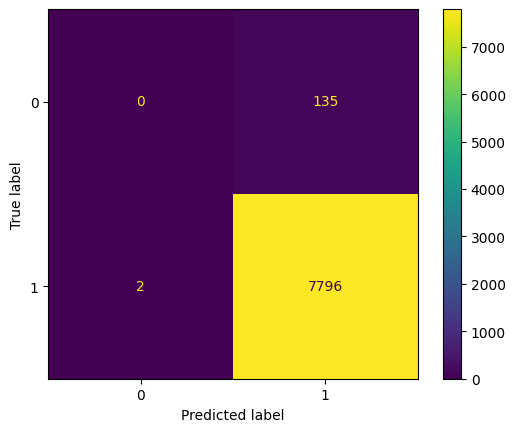

In [94]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [95]:
results_df = results_df.sort_values(
    by='F2-Score',
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Recall,Precision,Accuracy,F1-Score,F2-Score,ROC-AUC
0,Logistic Regression,1.0000,0.9830,0.9830,0.9914,0.9965,0.8429
1,XGBoost,0.9997,0.9830,0.9827,0.9913,0.9963,0.8009
2,Random Forest,0.9967,0.9832,0.9800,0.9899,0.9939,0.7476


In [96]:
best_model_name = results_df.loc[0, 'Model']

print('Best Model:', best_model_name)

Best Model: Logistic Regression


### Business Interpretation

Berdasarkan hasil evaluasi, **Logistic Regression** dipilih sebagai model terbaik karena menghasilkan **F2-Score tertinggi sebesar 99.65%** dan Recall sebesar **100%**. Model ini mampu mengidentifikasi customer yang berpotensi melakukan claim dengan sangat baik, sehingga dapat membantu perusahaan dalam melakukan **risk assessment dan perencanaan pengelolaan claim**. Namun, model masih perlu diperhatikan dalam mengidentifikasi customer yang tidak melakukan claim karena terdapat False Positive.
